<a href="https://colab.research.google.com/github/beyzanurkeles/beyzanurkeles/blob/main/ISPY_nnUNet_v2__data_augmentation_eklenmis_hali.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# gpu_info = !nvidia-smi
# gpu_info = '\n'.join(gpu_info)
# if gpu_info.find('failed') >= 0:
#   print('Not connected to a GPU')
# else:
#   print(gpu_info)

Çok Net Görüntülerle ile Augmentation ile Eğitim (400 veri)

Google Drive’ı bağlama ✅

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Kütüphane kurulumu ✅

Gereksiz/çakışan paketleri kaldırma
(önceden yüklenmiş nnUNet veya mmcv paketleri varsa temizler)

In [ ]:
!pip uninstall -y nnunet nnunetv2 mmcv mmcv-full mmdet openmim || true


pip / wheel / setuptools güncelleme ✅

---



In [ ]:
!pip install --upgrade pip wheel setuptools


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 41.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 62.5 MB/s eta 0:00:00
  Attempting uninstall: setuptools
    Found existing installation: setuptools 75.2.0
    Uninstalling setuptools-75.2.0:
      Successfully uninstalled setuptools-75.2.0
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.


In [ ]:
# ================================
# 4. nnU-Net için gerekli kütüphaneler (güncel)
# - nibabel: .nii.gz medikal görüntüler
# - batchgeneratorsv2: yeni augmentasyon altyapısı (nnU-Net >= v2.5 ile uyumlu)
# - SimpleITK, scikit-image, scikit-learn: görüntü işleme / preprocess
# - pandas, tqdm, matplotlib: raporlama, loglama
# ================================
!pip install nibabel batchgeneratorsv2 SimpleITK scikit-image scikit-learn pandas tqdm matplotlib


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 77.9 MB/s  0:00:00
  Created wheel for batchgeneratorsv2: filename=batchgeneratorsv2-0.3.0-py3-none-any.whl size=65215 sha256=25d4587ac1ee0aec2d69febcf572c2344ebc37e495e7c34bdf8e29abce116f83
  Stored in directory: /root/.cache/pip/wheels/9d/99/a0/1224a58f286be9fedbdb256d41e782a63b5ecab743e92ed302
  Created wheel for batchgenerators: filename=batchgenerators-0.25.1-py3-none-any.whl size=93163 sha256=467f198f7068f4b25c2086941e895d9e495ce9d4118219a1a231d3a1675747ca
  Stored in directory: /root/.cache/pip/wheels/28/21/2b/7b25080f9f5847e6c3162b89d859d7cec9f3093158e56bd008
Successfully built batchgeneratorsv2 batchgenerators
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/

PyTorch kurulumu

In [ ]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118


Looking in indexes: https://download.pytorch.org/whl/cu118


Kütüphane Kontrolu

In [ ]:
# Kontrol
import nibabel as nib
print("Nibabel version:", nib.__version__)

import batchgenerators
from batchgenerators.dataloading.multi_threaded_augmenter import MultiThreadedAugmenter

print("Batchgenerators OK ✅")

Nibabel version: 5.3.2
Batchgenerators OK ✅


In [ ]:
import torch
print("Torch version:", torch.__version__)
print("CUDA build     :", torch.version.cuda)
print("CUDA available :", torch.cuda.is_available())
print("GPU count      :", torch.cuda.device_count())
if torch.cuda.is_available():
    print("GPU name       :", torch.cuda.get_device_name(0))

Torch version: 2.8.0+cu126
CUDA build     : 12.6
CUDA available : True
GPU count      : 1
GPU name       : Tesla T4


nnUNet v2 kodunu klonla

In [ ]:
# güvenli köke dön
%cd /content

# varsa eski klasörü temizle (önceki denemelerden kalma olabilir)
!rm -rf /content/nnUNet

# klonla
!git clone https://github.com/MIC-DKFZ/nnUNet.git /content/nnUNet
%cd /content/nnUNet

# 🔴 kritik: pyproject.toml'u geçici olarak pasifleştir (editable install için)
!mv pyproject.toml pyproject.toml.bak

# setup.py tabanlı editable kurulum (build izolasyonunu kapat)
!pip install -e . --no-build-isolation


/content
Cloning into '/content/nnUNet'...
remote: Enumerating objects: 14008, done.
remote: Counting objects: 100% (2/2), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 14008 (delta 0), reused 0 (delta 0), pack-reused 14006 (from 2)
Receiving objects: 100% (14008/14008), 8.61 MiB | 37.99 MiB/s, done.
Resolving deltas: 100% (10703/10703), done.
/content/nnUNet
Obtaining file:///content/nnUNet
  Checking if build backend supports build_editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for nnunetv2 (pyproject.toml) ... done
  Created wheel for nnunetv2: filename=nnunetv2-0.0.0-0.editable-py3-none-any.whl size=6887 sha256=6816f5eec9816f960463140fb96334c14533e06ab57395b1505ebaa0aa9bce2e
  Stored in directory: /tmp/pip-ephem-wheel-cache-_5jrk7gx/wheels/e4/49/54/747a776959ad4bad6675565e9c9011de0787353cf8a2e4683d
Successfully built nnunetv2


In [ ]:
import shutil, nnunetv2
print("Has nnUNetv2_train? ->", shutil.which("nnUNetv2_train") is not None)


Has nnUNetv2_train? -> False


In [ ]:
import os, stat, shutil

bin_dir = "/usr/local/bin"
scripts = {
    "nnUNetv2_train": "python -m nnunetv2.run.run_training \"$@\"",
    "nnUNetv2_predict": "python -m nnunetv2.run.run_inference \"$@\"",
}

for name, cmd in scripts.items():
    path = os.path.join(bin_dir, name)
    with open(path, "w") as f:
        f.write(f"#!/usr/bin/env bash\n{cmd}\n")
    st = os.stat(path)
    os.chmod(path, st.st_mode | stat.S_IEXEC)

print("✅ Wrapper CLI scriptleri yazıldı")
print("Has nnUNetv2_train? ->", shutil.which("nnUNetv2_train") is not None)
print("Has nnUNetv2_predict? ->", shutil.which("nnUNetv2_predict") is not None)



✅ Wrapper CLI scriptleri yazıldı
Has nnUNetv2_train? -> True
Has nnUNetv2_predict? -> True


In [ ]:
!nnUNetv2_train -h | head -n 15
!nnUNetv2_predict -h | head -n 15


Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/content/nnUNet/nnunetv2/run/run_training.py", line 13, in <module>
    from nnunetv2.training.nnUNetTrainer.nnUNetTrainer import nnUNetTrainer
  File "/content/nnUNet/nnunetv2/training/nnUNetTrainer/nnUNetTrainer.py", line 25, in <module>
    from batchgeneratorsv2.transforms.nnunet.remove_connected_components import \
  File "/usr/local/lib/python3.12/dist-packages/batchgeneratorsv2/transforms/nnunet/remove_connected_components.py", line 5, in <module>
    from acvl_utils.morphology.morphology_helper import label_with_component_sizes
ModuleNotFoundError: No module named 'acvl_utils'
nnUNet_raw is not defined and nnU-Net can only be used on data for which preprocessed files are already present on your system. nnU-Net cannot be used for experiment planning and preprocessing like this. If this is not intended, please read documentation/setti

Ortam değişkenlerini ayarlama ✅

In [ ]:
import os, pathlib

os.environ["nnUNet_raw"] = "/content/drive/MyDrive/nnUNet_raw_data"
os.environ["nnUNet_preprocessed"] = "/content/drive/MyDrive/nnUNet_preprocessed"
os.environ["nnUNet_results"] = "/content/drive/MyDrive/nnUNet_trained_models"

print("ENV paths set ✅")
print("nnUNet_raw ->", os.environ["nnUNet_raw"])
print("nnUNet_preprocessed ->", os.environ["nnUNet_preprocessed"])
print("nnUNet_results ->", os.environ["nnUNet_results"])


ENV paths set ✅
nnUNet_raw -> /content/drive/MyDrive/nnUNet_raw_data
nnUNet_preprocessed -> /content/drive/MyDrive/nnUNet_preprocessed
nnUNet_results -> /content/drive/MyDrive/nnUNet_trained_models


Bunların doğru görünüp görünmediğini test etme

In [ ]:
import os
print("nnUNet_raw:", os.environ.get("nnUNet_raw"))
print("nnUNet_preprocessed:", os.environ.get("nnUNet_preprocessed"))
print("nnUNet_results:", os.environ.get("nnUNet_results"))


nnUNet_raw: /content/drive/MyDrive/nnUNet_raw_data
nnUNet_preprocessed: /content/drive/MyDrive/nnUNet_preprocessed
nnUNet_results: /content/drive/MyDrive/nnUNet_trained_models


dataset.json oluşturma ✅

In [ ]:
import json

with open('/content/drive/MyDrive/nnUNet_raw_data/Dataset001_MyTestTask/dataset.json') as f:
    data = json.load(f)
print(json.dumps(data, indent=4))

# # with open('/content/drive/MyDrive/nnUNet_raw_data/Dataset001_MyTestTask/dataset.json') as f:
# #     data = json.load(f)
# # print(json.dumps(data, indent=2))


Trainer Sınıfını Tanımla

Trainer’ı oluşturma (augmentation aktif versiyon)

In [ ]:
trainer_path = "/content/nnUNet/nnunetv2/training/nnUNetTrainer/nnUNetTrainer_300epochs_augmented.py"

code = """
from nnunetv2.training.nnUNetTrainer.nnUNetTrainer import nnUNetTrainer
import torch

class nnUNetTrainer_300epochs_augmented(nnUNetTrainer):
    def __init__(self, plans: dict, configuration: str, fold: int,
                 dataset_json: dict, device=None):
        if isinstance(device, bool):
            device = torch.device('cuda' if (device and torch.cuda.is_available()) else 'cpu')
        elif isinstance(device, str):
            device = torch.device(device)
        elif device is None:
            device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

        super().__init__(plans=plans,
                         configuration=configuration,
                         fold=fold,
                         dataset_json=dataset_json,
                         device=device)

        # 🧠 Eğitim ayarları
        self.num_epochs = 300
        self.do_augmentation = True

        # 🎨 Data augmentation parametreleri (manuel)
        self.data_aug_params = {
            "rotation_x": (-0.35, 0.35),
            "rotation_y": (-0.35, 0.35),
            "rotation_z": (-0.35, 0.35),
            "scale_range": (0.7, 1.4),
            "do_elastic": True,
            "p_eldef": 0.25,
            "do_gamma": True,
            "gamma_range": (0.7, 1.5),
            "p_gamma": 0.5,
            "do_mirror": True,
            "mirror_axes": (0, 1, 2),
        }

        print("✅ Data augmentation aktif ve parametreler manuel olarak tanımlandı.")
"""
with open(trainer_path, "w") as f:
    f.write(code.strip())

print("✅ Trainer dosyası yazıldı (manual augmentation ile, import gerektirmiyor).")


✅ Trainer dosyası yazıldı (manual augmentation ile, import gerektirmiyor).


In [ ]:
import os, shutil, sys, subprocess
for root, dirs, files in os.walk("/content/nnUNet/nnunetv2"):
    if "__pycache__" in dirs:
        shutil.rmtree(os.path.join(root, "__pycache__"), ignore_errors=True)
subprocess.check_call([sys.executable, "-m", "pip", "install", "-e", "/content/nnUNet", "--no-build-isolation"])
print("♻️ nnUNet paketi yeniden tanıtıldı.")


♻️ nnUNet paketi yeniden tanıtıldı.


In [ ]:
import os

os.environ["nnUNet_raw"] = "/content/drive/MyDrive/nnUNet_raw_data"
os.environ["nnUNet_preprocessed"] = "/content/drive/MyDrive/nnUNet_preprocessed"
os.environ["nnUNet_results"] = "/content/drive/MyDrive/nnUNet_trained_models"

print("ENV paths set ✅")


ENV paths set ✅


In [ ]:
!pip install acvl-utils


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached argparse-1.4.0-py2.py3-none-any.whl.metadata (2.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 43.9 MB/s  0:00:00
Using cached argparse-1.4.0-py2.py3-none-any.whl (23 kB)
  Created wheel for acvl-utils: filename=acvl_utils-0.2.5-py3-none-any.whl size=27243 sha256=55ebeb922bbf70825819be4694973c73ee7fa6414dda79bcd477fe5f631e42c1
  Stored in directory: /root/.cache/pip/wheels/70/c4/16/bae888b32a033f634d91a14256a8f8c8ec97db4e4dad8f0216
Successfully built acvl-utils
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [acvl-utils]


In [ ]:
!pip install dynamic-network-architectures


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for dynamic-network-architectures: filename=dynamic_network_architectures-0.4.2-py3-none-any.whl size=39081 sha256=99f73c75cdc717ab0d9a2b41c27b1a422d7b44dbea7a98d8374f9129b5aa9bc3
  Stored in directory: /root/.cache/pip/wheels/c2/a8/c5/241ab34db40b3a6f498d2794411cc08a6309fefdc0d6e3d9f3
Successfully built dynamic-network-architectures


Planlama + Preprocess (Bu Aşama Verileri Eğitime Hazırlar)

nnUNet_preprocessed klasörü iiçindeki dosyaların tamamı silindiyse bu kodlar çalıştırılmalı

In [ ]:
# ==========================
# nnUNet Preprocess Ayarları
# ==========================

#  Drive'da nnUNet_preprocessed klasörü var mı kontrol et (boş olabilir)
!ls -lah "/content/drive/MyDrive/nnUNet_preprocessed" || echo "(Drive'da nnUNet_preprocessed bulunamadı)"

#  Yerel hedef klasörü sıfırla ve oluştur
!rm -rf "/content/nnUNet_preprocessed"
!mkdir -p "/content/nnUNet_preprocessed"

#  Environment değişkenleri
%env nnUNet_preprocessed=/content/nnUNet_preprocessed
%env nnUNet_results=/content/drive/MyDrive/nnUNet_trained_models
%env nnUNet_n_proc=8
%env nnUNet_n_proc_DA=8
%env OMP_NUM_THREADS=1
%env MKL_NUM_THREADS=1


total 4.0K
drwx------ 2 root root 4.0K Sep 30 16:32 Dataset001_MyTestTask
env: nnUNet_preprocessed=/content/nnUNet_preprocessed
env: nnUNet_results=/content/drive/MyDrive/nnUNet_trained_models
env: nnUNet_n_proc=8
env: nnUNet_n_proc_DA=8
env: OMP_NUM_THREADS=1
env: MKL_NUM_THREADS=1


In [ ]:
#  CLI komutlarını yeniden tanıt
import os, stat, shutil

bin_dir = "/usr/local/bin"
scripts = {
    "nnUNetv2_train": "python -m nnunetv2.run.run_training \"$@\"",
    "nnUNetv2_predict": "python -m nnunetv2.run.run_inference \"$@\"",
    "nnUNetv2_plan_and_preprocess": "python -m nnunetv2.run.run_plan_and_preprocess \"$@\"",
}

for name, cmd in scripts.items():
    path = os.path.join(bin_dir, name)
    with open(path, "w") as f:
        f.write(f"#!/usr/bin/env bash\n{cmd}\n")
    st = os.stat(path)
    os.chmod(path, st.st_mode | stat.S_IEXEC)

print("✅ Wrapper CLI scriptleri yazıldı:")
for k in scripts:
    print(f" - {k}: {shutil.which(k) is not None}")

✅ Wrapper CLI scriptleri yazıldı:
 - nnUNetv2_train: True
 - nnUNetv2_predict: True
 - nnUNetv2_plan_and_preprocess: True


In [ ]:
#  Planlama + Preprocess (boş klasörü yeniden doldurur)
!python -m nnunetv2.experiment_planning.plan_and_preprocess_entrypoints \
    -d 1 -c 3d_fullres -np 8 --verify_dataset_integrity


Fingerprint extraction...
Dataset001_MyTestTask
Using <class 'nnunetv2.imageio.simpleitk_reader_writer.SimpleITKIO'> as reader/writer

####################
verify_dataset_integrity Done. 
If you didn't see any error messages then your dataset is most likely OK!
####################

Using <class 'nnunetv2.imageio.simpleitk_reader_writer.SimpleITKIO'> as reader/writer
100% 320/320 [00:32<00:00,  9.81it/s]
Experiment planning...

############################
INFO: You are using the old nnU-Net default planner. We have updated our recommendations. Please consider using those instead! Read more here: https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/resenc_presets.md
############################

Dropping 3d_lowres config because the image size difference to 3d_fullres is too small. 3d_fullres: [ 80.  249.  251.5], 3d_lowres: [80, 249, 252]
2D U-Net configuration:
{'data_identifier': 'nnUNetPlans_2d', 'preprocessor_name': 'DefaultPreprocessor', 'batch_size': 49, 'patch_size': (n

In [ ]:
!ls -lah /content/nnUNet_preprocessed | head -n 10


total 12K
drwxr-xr-x 3 root root 4.0K Nov  4 13:05 .
drwxr-xr-x 1 root root 4.0K Nov  4 13:00 ..
drwxr-xr-x 4 root root 4.0K Nov  4 13:11 Dataset001_MyTestTask


Preprocessed’ı Drive → yerel disk (/content) kopyalama

In [ ]:
# # Drive'da preprocessed var mı, görelim
# !ls -lah "/content/drive/MyDrive/nnUNet_preprocessed" || echo "(Drive'da nnUNet_preprocessed bulunamadı)"

# # Yerel hedefi sıfırla & oluştur
# !rm -rf "/content/nnUNet_preprocessed"
# !mkdir -p "/content/nnUNet_preprocessed"

# # Drive → Yerel kopya (veri büyükse biraz sürebilir)
# !cp -r "/content/drive/MyDrive/nnUNet_preprocessed/"* "/content/nnUNet_preprocessed/"

# # Kısa kontrol
# !ls -lah "/content/nnUNet_preprocessed" | head -n 20


In [ ]:
# # Veriyi HIZLI yerelden oku
# %env nnUNet_preprocessed=/content/nnUNet_preprocessed

# # Çıktıları (checkpoint/log) Drive'a yaz (kalıcı olsun)
# %env nnUNet_results=/content/drive/MyDrive/nnUNet_trained_models

# # Hız: veri yükleme/augmentasyon işçileri (CPU'na göre 6–12 arası deneyebilirsin)
# %env nnUNet_n_proc=8
# %env nnUNet_n_proc_DA=8

# # (Opsiyonel) CPU'da gereksiz fazla thread açılmasın
# %env OMP_NUM_THREADS=1
# %env MKL_NUM_THREADS=1


In [ ]:
# import os, stat, shutil

# bin_dir = "/usr/local/bin"
# scripts = {
#     "nnUNetv2_train": "python -m nnunetv2.run.run_training \"$@\"",
#     "nnUNetv2_predict": "python -m nnunetv2.run.run_inference \"$@\"",
#     "nnUNetv2_plan_and_preprocess": "python -m nnunetv2.run.run_plan_and_preprocess \"$@\"",
# }

# for name, cmd in scripts.items():
#     path = os.path.join(bin_dir, name)
#     with open(path, "w") as f:
#         f.write(f"#!/usr/bin/env bash\n{cmd}\n")
#     st = os.stat(path)
#     os.chmod(path, st.st_mode | stat.S_IEXEC)

# print("✅ Wrapper CLI scriptleri yazıldı:")
# for k in scripts:
#     print(f" - {k}: {shutil.which(k) is not None}")


✅ Wrapper CLI scriptleri yazıldı:
 - nnUNetv2_train: True
 - nnUNetv2_predict: True
 - nnUNetv2_plan_and_preprocess: True


In [ ]:
# !python -m nnunetv2.experiment_planning.plan_and_preprocess_entrypoints -d 1 -c 3d_fullres -np 8 --verify_dataset_integrity


Fingerprint extraction...
Dataset001_MyTestTask
Using <class 'nnunetv2.imageio.simpleitk_reader_writer.SimpleITKIO'> as reader/writer

####################
verify_dataset_integrity Done. 
If you didn't see any error messages then your dataset is most likely OK!
####################

Using <class 'nnunetv2.imageio.simpleitk_reader_writer.SimpleITKIO'> as reader/writer
100% 320/320 [00:32<00:00,  9.96it/s]
Experiment planning...

############################
INFO: You are using the old nnU-Net default planner. We have updated our recommendations. Please consider using those instead! Read more here: https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/resenc_presets.md
############################

Dropping 3d_lowres config because the image size difference to 3d_fullres is too small. 3d_fullres: [ 80.  249.  251.5], 3d_lowres: [80, 249, 252]
2D U-Net configuration:
{'data_identifier': 'nnUNetPlans_2d', 'preprocessor_name': 'DefaultPreprocessor', 'batch_size': 49, 'patch_size': (n

Eğitim

In [ ]:
!pkill -f nnUNetv2_train || true


^C


In [ ]:
# =====================================
# 🧹 1️⃣ TEMİZLİK (varsa eski süreçleri kapat)
# =====================================
!pkill -f nnUNetv2_train || true


^C


In [ ]:
# =====================================
# ⚙️ 2️⃣ ORTAM DEĞİŞKENLERİ (hem Python hem Bash için)
# =====================================
%env nnUNet_preprocessed=/content/nnUNet_preprocessed
%env nnUNet_results=/content/drive/MyDrive/nnUNet_trained_models
%env nnUNet_n_proc=12
%env nnUNet_n_proc_DA=12
%env nnUNet_compile=0
%env OMP_NUM_THREADS=1
%env MKL_NUM_THREADS=1
%env TORCHINDUCTOR_COMPILE_THREADS=1

!echo "preproc -> $nnUNet_preprocessed"
!echo "results -> $nnUNet_results"

env: nnUNet_preprocessed=/content/nnUNet_preprocessed
env: nnUNet_results=/content/drive/MyDrive/nnUNet_trained_models
env: nnUNet_n_proc=12
env: nnUNet_n_proc_DA=12
env: nnUNet_compile=0
env: OMP_NUM_THREADS=1
env: MKL_NUM_THREADS=1
env: TORCHINDUCTOR_COMPILE_THREADS=1
preproc -> /content/nnUNet_preprocessed
results -> /content/drive/MyDrive/nnUNet_trained_models


In [ ]:
# Aynı ortam değişkenlerini bash tarafında da set et
%%bash
export nnUNet_preprocessed=/content/nnUNet_preprocessed
export nnUNet_results=/content/drive/MyDrive/nnUNet_trained_models
export nnUNet_n_proc=12
export nnUNet_n_proc_DA=12
export nnUNet_compile=0
export OMP_NUM_THREADS=1
export MKL_NUM_THREADS=1
echo "✅ Bash ortam değişkenleri tanımlandı."

✅ Bash ortam değişkenleri tanımlandı.


In [ ]:
# =====================================
# 🔧 3️⃣ KÜÇÜK GÜVENLİK AYARLARI
# =====================================
import os
os.environ["TORCHINDUCTOR_COMPILE_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
print("✅ TORCHINDUCTOR_COMPILE_THREADS ve thread ayarları tamamlandı.")

✅ TORCHINDUCTOR_COMPILE_THREADS ve thread ayarları tamamlandı.


In [ ]:
# =====================================
# 🧠 4️⃣ run_training.py dosyasını düzenle (tip hatasını düzeltmek için)
# =====================================
file_path = "/content/nnUNet/nnunetv2/run/run_training.py"

fixed_block = """if __name__ == '__main__':
    os.environ['OMP_NUM_THREADS'] = '1'
    os.environ['MKL_NUM_THREADS'] = '1'
    os.environ['OPENBLAS_NUM_THREADS'] = '1'
    # reduces the number of threads used for compiling. More threads don't help and can cause problems
    os.environ['TORCHINDUCTOR_COMPILE_THREADS'] = '1'
    run_training_entry()
"""

# Eski bloğu kaldırıp yenisini ekle
with open(file_path, "r", encoding="utf-8") as f:
    lines = f.readlines()

start = None
for i, line in enumerate(lines):
    if "if __name__ == '__main__':" in line:
        start = i
        break

if start is not None:
    lines = lines[:start] + [fixed_block]

with open(file_path, "w", encoding="utf-8") as f:
    f.writelines(lines)

print("✅ run_training.py son bloğu doğru biçimde yeniden yazıldı.")

✅ run_training.py son bloğu doğru biçimde yeniden yazıldı.


🚀 5️⃣ FOLD=ALL EĞİTİMİ BAŞLAT
      (fold=all → 5 fold’un tamamı eğitilir.)

In [ ]:
!nnUNetv2_train 1 3d_fullres all -tr nnUNetTrainer_300epochs_augmented --npz



############################
INFO: You are using the old nnU-Net default plans. We have updated our recommendations. Please consider using those instead! Read more here: https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/resenc_presets.md
############################

Using device: cuda:0

#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

✅ Data augmentation aktif ve parametreler manuel olarak tanımlandı.
2025-11-04 14:18:25.442257: do_dummy_2d_data_aug: True
using pin_memory on device 0
using pin_memory on device 0

This is the configuration used by this training:
Configuration name: 3d_fullres
 {'data_identifier': 'nnUNetPlans_

In [ ]:

!nnUNetv2_train 1 3d_fullres all -tr nnUNetTrainer_300epochs_augmented --npz

6️⃣ Eğitimin ilerleyişini izle (canlı log)

In [ ]:
!tail -f "/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/nnUNetTrainer_300epochs_augmented__3d_fullres/fold_all/train.log"


*BAĞLANTI KOPARSA*                   
Koparsa HER SEFERİNDE kullanacağın “devam” hücresi (BASH)

Bu hücre checkpoint varsa devam eder, yoksa sıfırdan başlatır—tek komutla kurtarma.

In [ ]:
# %%bash
# set -euo pipefail
# # Güvenlik: açık süreçleri kapat
# pkill -f nnUNetv2_train || true

# # Env'ler
# export nnUNet_preprocessed=/content/nnUNet_preprocessed
# export nnUNet_results=/content/drive/MyDrive/nnUNet_trained_models
# export nnUNet_n_proc=12
# export nnUNet_n_proc_DA=12
# export nnUNet_compile=0
# export OMP_NUM_THREADS=1
# export MKL_NUM_THREADS=1

# # Checkpoint var mı?
# RUN_DIR="$nnUNet_results/Dataset001_MyTestTask/nnUNetTrainer_300epochs__nnUNetPlans__3d_fullres/fold_all"
# LOG="$nnUNet_results/logs/fold_all.log"
# mkdir -p "$(dirname "$LOG")"
# MODE=fresh
# [ -f "$RUN_DIR/checkpoint_latest.pth" ] && MODE=continue

# # Başlat
# if [ "$MODE" = "continue" ]; then
#   nohup nnUNetv2_train 1 3d_fullres all -tr nnUNetTrainer_300epochs -p nnUNetPlans --c \
#     > "$LOG" 2>&1 & echo "PID:$!  (continue)"
# else
#   nohup nnUNetv2_train 1 3d_fullres all -tr nnUNetTrainer_300epochs -p nnUNetPlans \
#     > "$LOG" 2>&1 & echo "PID:$!  (fresh)"
# fi
# sleep 3
# tail -n 80 "$LOG" || true


*********************************************************************************************************************************************************************************************************************************************

5 fold’un her birinin validation_summary.json dosyasını okuma,

Her sınıf için (örn. background, lesion) Dice, HD95, ASSD değerlerini toplama,

Fold’ların ortalamasını ve standart sapmasını hesaplama,

Bunu CSV dosyası olarak kaydetme.

<!-- /content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/ -->
  └── nnUNetTrainer_300epochs_augmented__nnUNetPlans__3d_fullres/
        ├── fold_0/
        │     ├── validation_summary.json  ❓
        ├── fold_1/
        ├── fold_2/
        ├── fold_3/
        └── fold_4/

In [ ]:
import glob, os

base = "/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask"
paths = glob.glob(os.path.join(base, "**/*.json"), recursive=True)
for p in paths:
    print(p)


/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/nnUNetTrainer_300epochs_augmented__nnUNetPlans__3d_fullres/plans.json
/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/nnUNetTrainer_300epochs_augmented__nnUNetPlans__3d_fullres/dataset.json
/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/nnUNetTrainer_300epochs_augmented__nnUNetPlans__3d_fullres/dataset_fingerprint.json
/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/nnUNetTrainer_300epochs_augmented__nnUNetPlans__3d_fullres/fold_all/debug.json
/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/nnUNetTrainer_300epochs_augmented__nnUNetPlans__3d_fullres/fold_all/validation/summary.json
/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/nnUNetTrainer_300epochs_augmented__nnUNetPlans__3d_fullres/fold_all/validation/postprocessing.json
/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/test_predictions_augmented/predict_

In [ ]:
import os, json, pandas as pd, numpy as np

# === Yol tanımları ===
BASE = "/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask"
RUN  = os.path.join(BASE, "nnUNetTrainer_300epochs_augmented__nnUNetPlans__3d_fullres")
OUT_DIR = os.path.join(BASE, "reports_augmented")
os.makedirs(OUT_DIR, exist_ok=True)

# fold_all summary dosyası
summary_path = os.path.join(RUN, "fold_all", "validation", "summary.json")

if not os.path.exists(summary_path):
    raise FileNotFoundError(f"❌ Dosya bulunamadı: {summary_path}")

# --------------------------
# 1️⃣ Dosyayı oku
# --------------------------
with open(summary_path, "r") as f:
    summary = json.load(f)

# --------------------------
# 2️⃣ Metrikleri çözümle
# --------------------------
# Yapıya göre çözümleme (nnUNet v2 summary formatı)
metrics = {}

if "foreground_mean" in summary:
    metrics = summary["foreground_mean"]
elif "results" in summary:
    metrics = summary["results"]
else:
    metrics = summary  # fallback

# Tek satırlık tablo oluştur
df = pd.DataFrame([metrics])
csv_path = os.path.join(OUT_DIR, "fold_all_summary.csv")
df.to_csv(csv_path, index=False)

# --------------------------
# 3️⃣ Özet çıktılar
# --------------------------
print(f"✅ Metrikler CSV olarak kaydedildi:\n - {csv_path}\n")
print("📊 İçerik:")
print(df.head())


✅ Metrikler CSV olarak kaydedildi:
 - /content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/reports_augmented/fold_all_summary.csv

📊 İçerik:
       Dice      FN         FP       IoU            TN        TP      n_pred  \
0  0.839043  3305.9  4106.5125  0.737469  5.975869e+06  23260.95  27367.4625   

      n_ref  
0  26566.85  


In [ ]:
!ls -lh "/content/drive/MyDrive/nnUNet_raw_data/Dataset001_MyTestTask/imagesTs" | head


total 453M
-rw------- 1 root root 3.9M Feb  9  2025 ispy1_1005_0000.nii.gz
-rw------- 1 root root 4.1M Feb  9  2025 ispy1_1007_0000.nii.gz
-rw------- 1 root root 2.5M Feb  9  2025 ispy1_1017_0000.nii.gz
-rw------- 1 root root 2.8M Feb  9  2025 ispy1_1027_0000.nii.gz
-rw------- 1 root root 2.4M Feb  9  2025 ispy1_1036_0000.nii.gz
-rw------- 1 root root 3.3M Feb  9  2025 ispy1_1040_0000.nii.gz
-rw------- 1 root root 3.2M Feb  9  2025 ispy1_1053_0000.nii.gz
-rw------- 1 root root 3.8M Feb  9  2025 ispy1_1072_0000.nii.gz
-rw------- 1 root root 3.5M Feb  9  2025 ispy1_1082_0000.nii.gz


Post-processing Adımı

Validation Post-processing (karar oluşturma)

In [ ]:
import os, json, numpy as np, nibabel as nib
from scipy import ndimage
from tqdm import tqdm

VAL = "/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/nnUNetTrainer_300epochs_augmented__nnUNetPlans__3d_fullres/fold_all/validation"
GT  = "/content/drive/MyDrive/nnUNet_raw_data/Dataset001_MyTestTask/labelsTr"
OUT = os.path.join(VAL, "postprocessing.json")

def dice(a, b):
    inter = np.sum((a > 0) & (b > 0))
    return 2 * inter / (np.sum(a > 0) + np.sum(b > 0) + 1e-8)

records = []
for fname in tqdm(sorted(os.listdir(VAL))):
    if not fname.endswith(".nii.gz"):
        continue
    case = fname[:-7]
    pred_path = os.path.join(VAL, fname)
    gt_path   = os.path.join(GT, f"{case}.nii.gz")
    if not os.path.exists(gt_path):
        continue

    pred = nib.load(pred_path).get_fdata()
    gt   = nib.load(gt_path).get_fdata()

    d_all = dice(pred, gt)
    labeled, n = ndimage.label(pred > 0)
    if n > 0:
        sizes = ndimage.sum(pred > 0, labeled, range(1, n+1))
        keep = (sizes.argmax() + 1)
        filtered = (labeled == keep)
        d_lcc = dice(filtered, gt)
    else:
        d_lcc = d_all

    records.append({"case": case, "dice_raw": d_all, "dice_lcc": d_lcc})

mean_raw = np.mean([r["dice_raw"] for r in records])
mean_lcc = np.mean([r["dice_lcc"] for r in records])
use_lcc = bool(mean_lcc > mean_raw)  # <-- garantiye alındı!

postproc = {
    "use_largest_connected_component": bool(use_lcc),  # <-- dönüştürme eklendi!
    "mean_dice_raw": round(float(mean_raw), 4),
    "mean_dice_lcc": round(float(mean_lcc), 4)
}

with open(OUT, "w") as f:
    json.dump(postproc, f, indent=2)

print(f"✅ Validation post-processing tamamlandı → {OUT}")
print(json.dumps(postproc, indent=2))


100%|██████████| 962/962 [02:15<00:00,  7.11it/s]

✅ Validation post-processing tamamlandı → /content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/nnUNetTrainer_300epochs_augmented__nnUNetPlans__3d_fullres/fold_all/validation/postprocessing.json
{
  "use_largest_connected_component": false,
  "mean_dice_raw": 0.839,
  "mean_dice_lcc": 0.839
}


Test Tahmini (inference)

🔹 Model: nnUNetTrainer_300epochs_augmented
🔹 Girdi: imagesTs
🔹 Çıktı: test_predictions_augmented

In [ ]:
!ls -lh /content/nnUNet/nnunetv2/training/nnUNetTrainer | grep 300epochs


-rw-r--r--  1 root root 1.5K Nov  6 13:08 nnUNetTrainer_300epochs_augmented.py


In [ ]:
# 1️⃣ Pycache klasörlerini temizle
import os, shutil
for root, dirs, files in os.walk("/content/nnUNet/nnunetv2/training/nnUNetTrainer"):
    if "__pycache__" in dirs:
        shutil.rmtree(os.path.join(root, "__pycache__"), ignore_errors=True)
print("✅ __pycache__ temizlendi")


✅ __pycache__ temizlendi


In [ ]:
# 2️⃣ Trainer import edilebiliyor mu kontrol et
from nnunetv2.training.nnUNetTrainer.nnUNetTrainer_300epochs_augmented import nnUNetTrainer_300epochs_augmented
print("🎉 Trainer başarıyla bulundu:", nnUNetTrainer_300epochs_augmented)


🎉 Trainer başarıyla bulundu: <class 'nnunetv2.training.nnUNetTrainer.nnUNetTrainer_300epochs_augmented.nnUNetTrainer_300epochs_augmented'>


In [ ]:
!pip install -q acvl-utils dynamic-network-architectures

from nnunetv2.inference.predict_from_raw_data import nnUNetPredictor
import os

model_dir = "/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/nnUNetTrainer_300epochs_augmented__nnUNetPlans__3d_fullres"
input_dir = "/content/drive/MyDrive/nnUNet_raw_data/Dataset001_MyTestTask/imagesTs"
output_dir = "/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/test_predictions_augmented"

os.makedirs(output_dir, exist_ok=True)

predictor = nnUNetPredictor()
predictor.initialize_from_trained_model_folder(
    model_training_output_dir=model_dir,
    use_folds=('all',),
    checkpoint_name="checkpoint_best.pth"
)

predictor.predict_from_files_sequential(
    list_of_lists_or_source_folder=input_dir,
    output_folder_or_list_of_truncated_output_files=output_dir,
    save_probabilities=False,
    overwrite=True
)

print("✅ Test tahmini tamamlandı:", output_dir)


There are 80 cases in the source folder
I am processing 0 out of 1 (max process ID is 0, we start counting with 0!)
There are 80 cases that I would like to predict
perform_everything_on_device: True


100%|██████████| 4/4 [00:05<00:00,  1.48s/it]


perform_everything_on_device: True


100%|██████████| 8/8 [00:06<00:00,  1.15it/s]


perform_everything_on_device: True


...

perform_everything_on_device: True


100%|██████████| 18/18 [00:17<00:00,  1.05it/s]


perform_everything_on_device: True


100%|██████████| 8/8 [00:07<00:00,  1.08it/s]


✅ Test tahmini tamamlandı: /content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/test_predictions_augmented


Test Post-processing (temizlik)

🔹 Validation kararına göre (veya manuel olarak) küçük bileşenleri temizler
🔹 Çıktı: test_predictions_augmented_postprocessed

In [ ]:
import os, nibabel as nib, numpy as np
from scipy.ndimage import label
import json

# Validation karar dosyasını oku
VAL_DECISION = "/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/nnUNetTrainer_300epochs_augmented__nnUNetPlans__3d_fullres/fold_all/validation/postprocessing.json"
use_lcc = True
if os.path.exists(VAL_DECISION):
    use_lcc = json.load(open(VAL_DECISION))["use_largest_connected_component"]
print(f"📄 LCC kullanılacak mı? → {use_lcc}")

in_dir  = "/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/test_predictions_augmented"
out_dir = "/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/test_predictions_augmented_postprocessed"
os.makedirs(out_dir, exist_ok=True)

for f in os.listdir(in_dir):
    if not f.endswith(".nii.gz"):
        continue
    img = nib.load(os.path.join(in_dir, f))
    data = img.get_fdata()
    data_bin = (data > 0).astype(np.uint8)

    if use_lcc:
        lbl, n = label(data_bin)
        if n > 0:
            sizes = [(lbl == i).sum() for i in range(1, n+1)]
            largest = 1 + np.argmax(sizes)
            data_bin = (lbl == largest).astype(np.uint8)

    nib.save(
        nib.Nifti1Image(data_bin, img.affine, img.header),
        os.path.join(out_dir, f.replace(".nii.gz", "_postprocessed.nii.gz"))
    )

print("✅ Test post-processing tamamlandı.")
print("📂 Çıktılar:", out_dir)


📄 LCC kullanılacak mı? → False
✅ Test post-processing tamamlandı.
📂 Çıktılar: /content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/test_predictions_augmented_postprocessed


*********************************************** SONUÇ DEĞERLENDİRME *************************************

Hızlı Değerlendirme (örnek 5 satır + ortalama metrikler)

In [ ]:
import os
import numpy as np
import nibabel as nib
from scipy.spatial.distance import directed_hausdorff
from tqdm import tqdm
import pandas as pd

# 📁 klasörler
gt_dir = "/content/drive/MyDrive/nnUNet_raw_data/Dataset001_MyTestTask/labelsTs"
pred_dir = "/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/test_predictions_augmented_postprocessed"

# 🔧 metrik fonksiyonları
def dice_score(pred, gt):
    inter = np.sum((pred > 0) & (gt > 0))
    total = np.sum(pred > 0) + np.sum(gt > 0)
    return (2 * inter / total) if total > 0 else np.nan

def precision(pred, gt):
    tp = np.sum((pred > 0) & (gt > 0))
    fp = np.sum((pred > 0) & (gt == 0))
    return tp / (tp + fp) if (tp + fp) > 0 else np.nan

def recall(pred, gt):
    tp = np.sum((pred > 0) & (gt > 0))
    fn = np.sum((pred == 0) & (gt > 0))
    return tp / (tp + fn) if (tp + fn) > 0 else np.nan

def hd95(pred, gt):
    pred_pts = np.argwhere(pred > 0)
    gt_pts = np.argwhere(gt > 0)
    if len(pred_pts) == 0 or len(gt_pts) == 0:
        return np.nan
    d1 = directed_hausdorff(pred_pts, gt_pts)[0]
    d2 = directed_hausdorff(gt_pts, pred_pts)[0]
    return np.percentile([d1, d2], 95)

# 🔍 değerlendirme
results = []
for fname in tqdm(sorted(os.listdir(gt_dir))):
    if not fname.endswith(".nii.gz"):
        continue
    pred_path = os.path.join(pred_dir, fname.replace(".nii.gz", "_postprocessed.nii.gz"))
    gt_path = os.path.join(gt_dir, fname)
    if not os.path.exists(pred_path):
        print(f"⚠️ Missing prediction for {fname}")
        continue

    pred = nib.load(pred_path).get_fdata()
    gt = nib.load(gt_path).get_fdata()

    d = dice_score(pred, gt)
    p = precision(pred, gt)
    r = recall(pred, gt)
    h = hd95(pred, gt)
    results.append((fname, d, p, r, h))

# 📊 tablo
df = pd.DataFrame(results, columns=["Dosya", "Dice", "Precision", "Recall", "HD95"])
print(df.head())

print("\n🔹 Ortalama Değerler:")
print(df[["Dice", "Precision", "Recall", "HD95"]].mean())


100%|██████████| 80/80 [00:50<00:00,  1.59it/s]

               Dosya      Dice  Precision    Recall       HD95
0  ispy1_1005.nii.gz  0.818809   0.771021  0.872914  32.886209
1  ispy1_1007.nii.gz  0.610088   0.981755  0.442550  21.100594
2  ispy1_1017.nii.gz  0.849070   0.868339  0.830638  13.266496
3  ispy1_1027.nii.gz  0.916352   0.896212  0.937418   8.636216
4  ispy1_1036.nii.gz  0.712824   0.897306  0.591263  20.068756

🔹 Ortalama Değerler:
Dice          0.720538
Precision     0.769907
Recall        0.749100
HD95         47.867390
dtype: float64


Tam Performans Analizi + CSV Kaydı

In [ ]:
import os
import numpy as np
import nibabel as nib
import pandas as pd
from scipy.spatial.distance import directed_hausdorff
from tqdm import tqdm

# 📁 klasör yolları
gt_dir = "/content/drive/MyDrive/nnUNet_raw_data/Dataset001_MyTestTask/labelsTs"
pred_dir = "/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/test_predictions_augmented_postprocessed"
save_path = "/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/test_results_metrics_augmented.csv"

# 🔧 metrik fonksiyonları
def dice_score(pred, gt):
    inter = np.sum((pred > 0) & (gt > 0))
    total = np.sum(pred > 0) + np.sum(gt > 0)
    return (2 * inter / total) if total > 0 else np.nan

def precision(pred, gt):
    tp = np.sum((pred > 0) & (gt > 0))
    fp = np.sum((pred > 0) & (gt == 0))
    return tp / (tp + fp) if (tp + fp) > 0 else np.nan

def recall(pred, gt):
    tp = np.sum((pred > 0) & (gt > 0))
    fn = np.sum((pred == 0) & (gt > 0))
    return tp / (tp + fn) if (tp + fn) > 0 else np.nan

def hd95(pred, gt):
    pred_pts = np.argwhere(pred > 0)
    gt_pts = np.argwhere(gt > 0)
    if len(pred_pts) == 0 or len(gt_pts) == 0:
        return np.nan
    d1 = directed_hausdorff(pred_pts, gt_pts)[0]
    d2 = directed_hausdorff(gt_pts, pred_pts)[0]
    return np.percentile([d1, d2], 95)

# 🔍 değerlendirme
results = []
for fname in tqdm(sorted(os.listdir(gt_dir))):
    if not fname.endswith(".nii.gz"):
        continue
    pred_path = os.path.join(pred_dir, fname.replace(".nii.gz", "_postprocessed.nii.gz"))
    gt_path = os.path.join(gt_dir, fname)
    if not os.path.exists(pred_path):
        print(f"⚠️ Missing prediction for {fname}")
        continue

    pred = nib.load(pred_path).get_fdata()
    gt = nib.load(gt_path).get_fdata()

    results.append({
        "ID": fname.replace(".nii.gz", ""),
        "Dice": dice_score(pred, gt),
        "Precision": precision(pred, gt),
        "Recall": recall(pred, gt),
        "HD95": hd95(pred, gt)
    })

# 📊 CSV kayıt
df = pd.DataFrame(results)
df.to_csv(save_path, index=False)
print(f"✅ Tüm sonuçlar CSV olarak kaydedildi:\n{save_path}\n")

print("🔹 İlk 5 vaka:\n", df.head(), "\n")
print("🔸 Ortalama metrikler:\n", df[["Dice", "Precision", "Recall", "HD95"]].mean(), "\n")

best = df.sort_values("Dice", ascending=False).head(5)
worst = df.sort_values("Dice", ascending=True).head(5)

print("🌟 En iyi 5 vaka:")
print(best[["ID", "Dice", "Precision", "Recall", "HD95"]], "\n")

print("⚠️ En kötü 5 vaka:")
print(worst[["ID", "Dice", "Precision", "Recall", "HD95"]])


100%|██████████| 80/80 [00:29<00:00,  2.72it/s]

✅ Tüm sonuçlar CSV olarak kaydedildi:
/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/test_results_metrics_augmented.csv

🔹 İlk 5 vaka:
            ID      Dice  Precision    Recall       HD95
0  ispy1_1005  0.818809   0.771021  0.872914  32.886209
1  ispy1_1007  0.610088   0.981755  0.442550  21.100594
2  ispy1_1017  0.849070   0.868339  0.830638  13.266496
3  ispy1_1027  0.916352   0.896212  0.937418   8.636216
4  ispy1_1036  0.712824   0.897306  0.591263  20.068756 

🔸 Ortalama metrikler:
 Dice          0.720538
Precision     0.769907
Recall        0.749100
HD95         47.867390
dtype: float64 

🌟 En iyi 5 vaka:
              ID      Dice  Precision    Recall       HD95
25    ispy1_1169  0.937306   0.915269  0.960430   5.880278
5     ispy1_1040  0.934513   0.943842  0.925367  25.425469
77  ispy2_353318  0.921503   0.971365  0.876510   4.016950
3     ispy1_1027  0.916352   0.896212  0.937418   8.636216
60  ispy2_180027  0.916047   0.920282  0.911851   3.547748 

⚠

In [ ]:
# ========== TAM ANALİZ & GRAFİKLER (AUGMENTED MODEL) ==========
import os
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

# 📄 CSV yolu (augmented versiyon)
csv_path = "/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/test_results_metrics_augmented.csv"

# 0) CSV'yi oku
if not os.path.exists(csv_path):
    raise FileNotFoundError(f"CSV bulunamadı: {csv_path}")

df = pd.read_csv(csv_path)

# 1) Sütun adlarını temizle
df.columns = df.columns.str.strip().str.replace('\ufeff', '', regex=True).str.title()

# 2) Beklenen sütunlar
required = ["Id", "Dice", "Precision", "Recall", "Hd95"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise KeyError(f"Beklenen sütun(lar) eksik: {missing}\nMevcut sütunlar: {df.columns.tolist()}")

# 3) Numeriğe çevir
for c in ["Dice", "Precision", "Recall", "Hd95"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# 4) NaN temizliği
valid = df.dropna(subset=["Dice", "Precision", "Recall"])
n_all, n_valid = len(df), len(valid)

print("✅ Veri özeti")
print(f"Toplam vaka: {n_all} | Geçerli vaka: {n_valid}")
print(valid.head())

if n_valid == 0:
    raise ValueError("Hiç geçerli satır yok, metrikleri yeniden hesapla.")

# 📂 Grafik klasörü
outdir = "/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/figs_augmented"
os.makedirs(outdir, exist_ok=True)

# ===============================================================
# 1️⃣ Histogram (Dice, Precision, Recall)
plt.figure(figsize=(10,6))
for metric, color in zip(["Dice", "Precision", "Recall"], ["#1f77b4", "#ff7f0e", "#2ca02c"]):
    plt.hist(valid[metric].dropna().values, bins=15, alpha=0.6, label=metric, color=color, edgecolor='black')
plt.xlabel("Metrik Değeri")
plt.ylabel("Frekans")
plt.title("Metrik Dağılımı (Test Seti)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(outdir, "hist_metrics.png"), dpi=150)
plt.show()

# ===============================================================
# 2️⃣ Boxplot
plt.figure(figsize=(8,6))
valid[["Dice", "Precision", "Recall"]].boxplot()
plt.title("Metriklerin Boxplot Gösterimi")
plt.ylabel("Değer")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(outdir, "boxplot_metrics.png"), dpi=150)
plt.show()

# ===============================================================
# 3️⃣ Hasta bazlı çizgi grafik
valid_sorted = valid.sort_values("Id")
plt.figure(figsize=(14,6))
for metric, marker in zip(["Dice", "Precision", "Recall"], ['o', 'x', '^']):
    plt.plot(valid_sorted["Id"].astype(str).values, valid_sorted[metric].values,
             marker=marker, label=metric, alpha=0.8)
plt.xticks(rotation=90)
plt.xlabel("Hasta ID")
plt.ylabel("Metrik Değeri")
plt.title("Her Hasta için Metrikler")
plt.legend()
plt.tight_layout()
plt.grid(True, linestyle="--", alpha=0.4)
plt.savefig(os.path.join(outdir, "line_id_metrics.png"), dpi=150)
plt.show()

# ===============================================================
# 4️⃣ Dice özel görselleştirme (hist + sıralı)
plt.figure(figsize=(6,5))
plt.hist(valid["Dice"], bins=15, color="#1f77b4", edgecolor="black")
plt.title("Dice Skorlarının Dağılımı")
plt.xlabel("Dice Skoru")
plt.ylabel("Hasta Sayısı")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(outdir, "dice_histogram.png"), dpi=150)
plt.show()

plt.figure(figsize=(6,5))
sorted_dice = np.sort(valid["Dice"].values)
plt.plot(sorted_dice, marker="o", color="#1f77b4")
plt.title("Her Hasta için Dice Skoru")
plt.xlabel("Hasta İndeksi")
plt.ylabel("Dice Skoru")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(outdir, "dice_per_patient.png"), dpi=150)
plt.show()

# ===============================================================
print("🖼️ Kaydedilen tüm grafikler:")
for f in os.listdir(outdir):
    if f.endswith(".png"):
        print(" -", os.path.join(outdir, f))

print("\n📊 Ortalama metrikler:")
print(valid[["Dice", "Precision", "Recall", "Hd95"]].mean())


✅ Veri özeti
Toplam vaka: 80 | Geçerli vaka: 80
           Id      Dice  Precision    Recall       Hd95
0  ispy1_1005  0.818809   0.771021  0.872914  32.886209
1  ispy1_1007  0.610088   0.981755  0.442550  21.100594
2  ispy1_1017  0.849070   0.868339  0.830638  13.266496
3  ispy1_1027  0.916352   0.896212  0.937418   8.636216
4  ispy1_1036  0.712824   0.897306  0.591263  20.068756
🖼️ Kaydedilen tüm grafikler:
 - /content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/figs_augmented/hist_metrics.png
 - /content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/figs_augmented/boxplot_metrics.png
 - /content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/figs_augmented/line_id_metrics.png
 - /content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/figs_augmented/dice_histogram.png
 - /content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/figs_augmented/dice_per_patient.png

📊 Ortalama metrikler:
Dice          0.720538
Precision     0.769

Orijinal görüntü boyutları (x, y, z): (256, 256, 64)
Bir slice seç (0 - 63 arası): 35


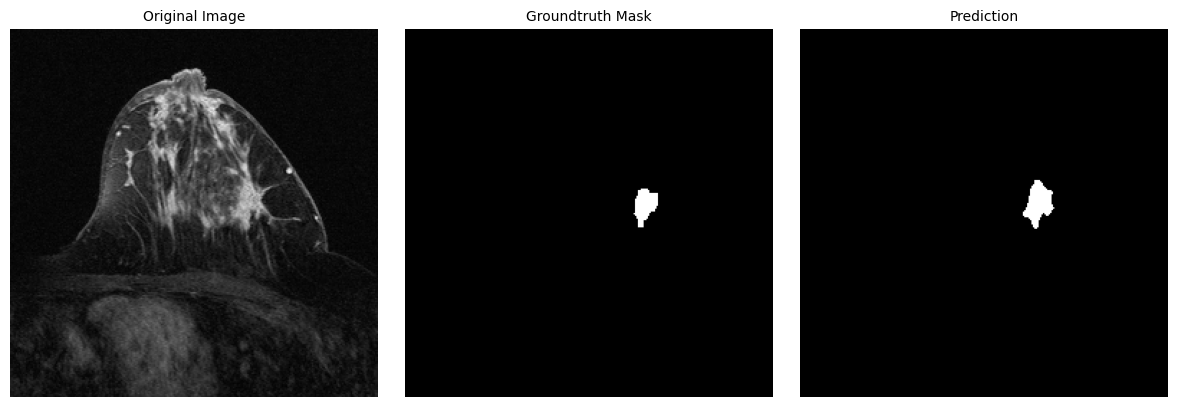

In [ ]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

# ==========================
# 1. Dosya yolları
# ==========================
original_path = "/content/drive/MyDrive/nnUNet_raw_data/Dataset001_MyTestTask/imagesTs/ispy1_1082_0000.nii.gz"
gt_path       = "/content/drive/MyDrive/nnUNet_raw_data/Dataset001_MyTestTask/labelsTs/ispy1_1082.nii.gz"
pred_path     = "/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/test_predictions_augmented/ispy1_1082.nii.gz"

# ==========================
# 2. Verileri yükle
# ==========================
original_img = nib.load(original_path).get_fdata()
gt           = nib.load(gt_path).get_fdata()
pred         = nib.load(pred_path).get_fdata()

# ==========================
# 3. Slice seç
# ==========================
print("Orijinal görüntü boyutları (x, y, z):", original_img.shape)
slice_idx = int(input(f"Bir slice seç (0 - {original_img.shape[2]-1} arası): "))

# ==========================
# 4. Görselleri hazırla
# ==========================
images = [
    original_img[:, :, slice_idx],
    gt[:, :, slice_idx],
    pred[:, :, slice_idx]
]
titles = ["Original Image", "Groundtruth Mask", "Prediction"]

# ==========================
# 5. Görselleştirme
# ==========================
plt.figure(figsize=(12, 4))
for i in range(len(images)):
    plt.subplot(1, len(images), i + 1)
    plt.imshow(images[i], cmap="gray")
    plt.title(titles[i], fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.show()


Orijinal görüntü boyutları (x, y, z): (256, 256, 64)
Bir slice seç (0 - 63 arası): 25


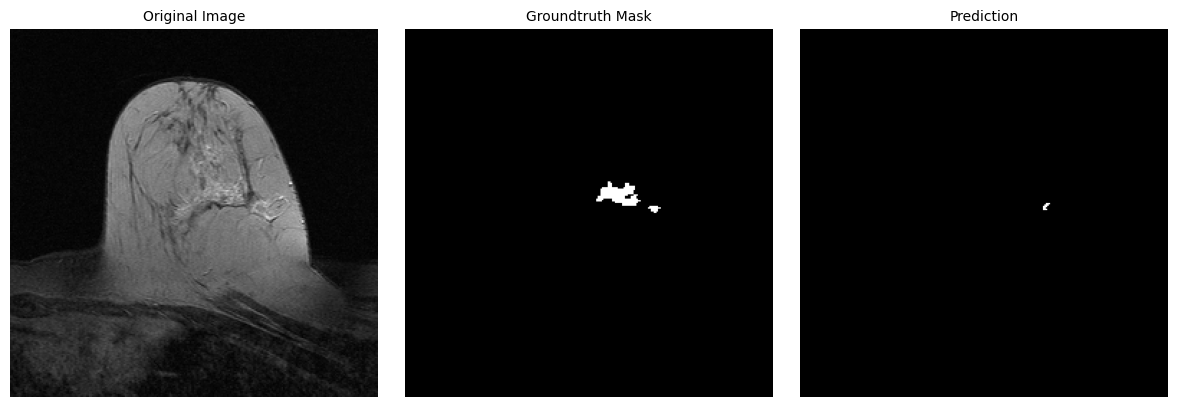

In [ ]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

# ==========================
# 1. Dosya yolları
# ==========================
original_path = "/content/drive/MyDrive/nnUNet_raw_data/Dataset001_MyTestTask/imagesTs/ispy1_1072_0000.nii.gz"
gt_path       = "/content/drive/MyDrive/nnUNet_raw_data/Dataset001_MyTestTask/labelsTs/ispy1_1072.nii.gz"
pred_path     = "/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/test_predictions_augmented/ispy1_1072.nii.gz"

# ==========================
# 2. Verileri yükle
# ==========================
original_img = nib.load(original_path).get_fdata()
gt           = nib.load(gt_path).get_fdata()
pred         = nib.load(pred_path).get_fdata()

# ==========================
# 3. Slice seç
# ==========================
print("Orijinal görüntü boyutları (x, y, z):", original_img.shape)
slice_idx = int(input(f"Bir slice seç (0 - {original_img.shape[2]-1} arası): "))

# ==========================
# 4. Görselleri hazırla
# ==========================
images = [
    original_img[:, :, slice_idx],
    gt[:, :, slice_idx],
    pred[:, :, slice_idx]
]
titles = ["Original Image", "Groundtruth Mask", "Prediction"]

# ==========================
# 5. Görselleştirme
# ==========================
plt.figure(figsize=(12, 4))
for i in range(len(images)):
    plt.subplot(1, len(images), i + 1)
    plt.imshow(images[i], cmap="gray")
    plt.title(titles[i], fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.show()


*********************************************** SONUÇ DEĞERLENDİRME *************************************

Hızlı değerlendirme (Dice, Precision, Recall, HD95)

In [ ]:
import os
import numpy as np
import nibabel as nib
from scipy.spatial.distance import directed_hausdorff
from tqdm import tqdm

# 📁 klasörler
gt_dir = "/content/drive/MyDrive/nnUNet_raw_data/Dataset001_MyTestTask/labelsTs"
pred_dir = "/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/test_predictions_postprocessed"

# 🔧 yardımcı fonksiyonlar
def dice_score(pred, gt):
    inter = np.sum((pred > 0) & (gt > 0))
    total = np.sum(pred > 0) + np.sum(gt > 0)
    return (2 * inter / total) if total > 0 else np.nan

def precision(pred, gt):
    tp = np.sum((pred > 0) & (gt > 0))
    fp = np.sum((pred > 0) & (gt == 0))
    return tp / (tp + fp) if (tp + fp) > 0 else np.nan

def recall(pred, gt):
    tp = np.sum((pred > 0) & (gt > 0))
    fn = np.sum((pred == 0) & (gt > 0))
    return tp / (tp + fn) if (tp + fn) > 0 else np.nan

def hd95(pred, gt):
    pred_pts = np.argwhere(pred > 0)
    gt_pts = np.argwhere(gt > 0)
    if len(pred_pts) == 0 or len(gt_pts) == 0:
        return np.nan
    d1 = directed_hausdorff(pred_pts, gt_pts)[0]
    d2 = directed_hausdorff(gt_pts, pred_pts)[0]
    return np.percentile([d1, d2], 95)

# 🔍 değerlendirme
results = []
for fname in tqdm(sorted(os.listdir(gt_dir))):
    if not fname.endswith(".nii.gz"):
        continue
    pred_path = os.path.join(pred_dir, fname.replace(".nii.gz", "_postprocessed.nii.gz"))
    gt_path = os.path.join(gt_dir, fname)

    if not os.path.exists(pred_path):
        print(f"⚠️ Missing prediction for {fname}")
        continue

    pred = nib.load(pred_path).get_fdata()
    gt = nib.load(gt_path).get_fdata()

    d = dice_score(pred, gt)
    p = precision(pred, gt)
    r = recall(pred, gt)
    h = hd95(pred, gt)

    results.append((fname, d, p, r, h))

# 📊 sonuçları tablo gibi göster
import pandas as pd
df = pd.DataFrame(results, columns=["Dosya", "Dice", "Precision", "Recall", "HD95"])
print(df.head())

print("\n🔹 Ortalama Değerler:")
print(df[["Dice", "Precision", "Recall", "HD95"]].mean())


100%|██████████| 80/80 [02:01<00:00,  1.51s/it]

               Dosya      Dice  Precision    Recall       HD95
0  ispy1_1005.nii.gz  0.782645   0.691506  0.901455  32.158584
1  ispy1_1007.nii.gz  0.596934   0.982806  0.428641  21.482977
2  ispy1_1017.nii.gz  0.845196   0.849246  0.841185  14.007852
3  ispy1_1027.nii.gz  0.924094   0.917283  0.931006   9.006894
4  ispy1_1036.nii.gz  0.736194   0.888302  0.628563  22.848118

🔹 Ortalama Değerler:
Dice          0.724631
Precision     0.805124
Recall        0.710195
HD95         24.429944
dtype: float64


Tam Performans Analizi (hasta ID bazlı + CSV kaydı + özet rapor)

In [ ]:
import os
import numpy as np
import nibabel as nib
import pandas as pd
from scipy.spatial.distance import directed_hausdorff
from tqdm import tqdm

# 📁 klasör yolları
gt_dir = "/content/drive/MyDrive/nnUNet_raw_data/Dataset001_MyTestTask/labelsTs"
pred_dir = "/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/test_predictions_postprocessed"
save_path = "/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/test_results_metrics.csv"

# 🔧 metrik fonksiyonları
def dice_score(pred, gt):
    inter = np.sum((pred > 0) & (gt > 0))
    total = np.sum(pred > 0) + np.sum(gt > 0)
    return (2 * inter / total) if total > 0 else np.nan

def precision(pred, gt):
    tp = np.sum((pred > 0) & (gt > 0))
    fp = np.sum((pred > 0) & (gt == 0))
    return tp / (tp + fp) if (tp + fp) > 0 else np.nan

def recall(pred, gt):
    tp = np.sum((pred > 0) & (gt > 0))
    fn = np.sum((pred == 0) & (gt > 0))
    return tp / (tp + fn) if (tp + fn) > 0 else np.nan

def hd95(pred, gt):
    pred_pts = np.argwhere(pred > 0)
    gt_pts = np.argwhere(gt > 0)
    if len(pred_pts) == 0 or len(gt_pts) == 0:
        return np.nan
    d1 = directed_hausdorff(pred_pts, gt_pts)[0]
    d2 = directed_hausdorff(gt_pts, pred_pts)[0]
    return np.percentile([d1, d2], 95)

# 🔍 değerlendirme
results = []
for fname in tqdm(sorted(os.listdir(gt_dir))):
    if not fname.endswith(".nii.gz"):
        continue
    pred_path = os.path.join(pred_dir, fname.replace(".nii.gz", "_postprocessed.nii.gz"))
    gt_path = os.path.join(gt_dir, fname)

    if not os.path.exists(pred_path):
        print(f"⚠️ Missing prediction for {fname}")
        continue

    pred = nib.load(pred_path).get_fdata()
    gt = nib.load(gt_path).get_fdata()

    results.append({
        "ID": fname.replace(".nii.gz", ""),
        "Dice": dice_score(pred, gt),
        "Precision": precision(pred, gt),
        "Recall": recall(pred, gt),
        "HD95": hd95(pred, gt)
    })

# 📊 sonuçları DataFrame olarak düzenle
df = pd.DataFrame(results)
df.to_csv(save_path, index=False)

print(f"✅ Tüm sonuçlar CSV olarak kaydedildi:\n{save_path}\n")
print("🔹 İlk 5 vaka:\n", df.head(), "\n")

# 🔹 Ortalama değerler
print("🔸 Ortalama metrikler:")
print(df[["Dice", "Precision", "Recall", "HD95"]].mean(), "\n")

# 🔹 En iyi / en kötü vakalar
best = df.sort_values("Dice", ascending=False).head(5)
worst = df.sort_values("Dice", ascending=True).head(5)

print("🌟 En iyi 5 vaka:")
print(best[["ID", "Dice", "Precision", "Recall", "HD95"]], "\n")

print("⚠️ En kötü 5 vaka:")
print(worst[["ID", "Dice", "Precision", "Recall", "HD95"]])


100%|██████████| 80/80 [00:49<00:00,  1.62it/s]

✅ Tüm sonuçlar CSV olarak kaydedildi:
/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/test_results_metrics.csv

🔹 İlk 5 vaka:
            ID      Dice  Precision    Recall       HD95
0  ispy1_1005  0.782645   0.691506  0.901455  32.158584
1  ispy1_1007  0.596934   0.982806  0.428641  21.482977
2  ispy1_1017  0.845196   0.849246  0.841185  14.007852
3  ispy1_1027  0.924094   0.917283  0.931006   9.006894
4  ispy1_1036  0.736194   0.888302  0.628563  22.848118 

🔸 Ortalama metrikler:
Dice          0.724631
Precision     0.805124
Recall        0.710195
HD95         24.429944
dtype: float64 

🌟 En iyi 5 vaka:
              ID      Dice  Precision    Recall       HD95
55  ispy2_132463  0.943752   0.954373  0.933365  11.651647
25    ispy1_1169  0.936535   0.921682  0.951875   7.074218
5     ispy1_1040  0.930177   0.937294  0.923169  19.854010
77  ispy2_353318  0.927862   0.967920  0.890988   4.016950
70  ispy2_301968  0.927573   0.911905  0.943790   4.475921 

⚠️ En kötü 5

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

csv_path = "/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/test_results_metrics.csv"
df = pd.read_csv(csv_path)

# Boş satırları temizleyelim
df = df.dropna(subset=["Dice", "Precision", "Recall", "HD95"])
df.head()


,ID,Dice,Precision,Recall,HD95
0,ispy1_1005,0.782645,0.691506,0.901455,32.158584
1,ispy1_1007,0.596934,0.982806,0.428641,21.482977
2,ispy1_1017,0.845196,0.849246,0.841185,14.007852
3,ispy1_1027,0.924094,0.917283,0.931006,9.006894
4,ispy1_1036,0.736194,0.888302,0.628563,22.848118


Grafikler

In [ ]:
# ========== GRAFİKLER (SAĞLAM) – UÇTAN UCA ==========
import os
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

csv_path = "/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/test_results_metrics.csv"

# 0) CSV'yi oku
if not os.path.exists(csv_path):
    raise FileNotFoundError(f"CSV bulunamadı: {csv_path}")

df = pd.read_csv(csv_path)

# 1) Sütun adlarını temizle
df.columns = df.columns.str.strip().str.replace('\ufeff', '', regex=True).str.title()

# 2) Beklenen sütunlar: Id, Dice, Precision, Recall, Hd95
required = ["Id", "Dice", "Precision", "Recall", "Hd95"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise KeyError(f"Beklenen sütun(lar) eksik: {missing}\nMevcut sütunlar: {df.columns.tolist()}")

# 3) Numeriğe çevir ve NaN'leri bildir
for c in ["Dice", "Precision", "Recall", "Hd95"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# 4) Boş/NaN satırları filtrele (grafikler için)
valid = df.dropna(subset=["Dice", "Precision", "Recall"])  # HD95 NaN olabilir, onu grafikte kullanmıyoruz
n_all, n_valid = len(df), len(valid)

print("✅ Veri özeti")
print("Matplotlib backend:", matplotlib.get_backend())
print(f"Toplam satır: {n_all}, Grafik için uygun satır: {n_valid}")
print("İlk 5 satır:")
print(valid.head())

# Eğer hiç veri yoksa erken çık
if n_valid == 0:
    raise ValueError("Grafik için uygun satır yok (tüm metrikler NaN). Lütfen metrik hesaplama hücresini yeniden çalıştır.")

# Çıktı klasörü
outdir = "/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/figs"
os.makedirs(outdir, exist_ok=True)

# ——————————————————————————
# 1) HISTOGRAM
plt.figure(figsize=(12,6))
for metric in ["Dice", "Precision", "Recall"]:
    if metric in valid.columns:
        plt.hist(valid[metric].dropna().values, bins=15, alpha=0.6, label=metric)
plt.xlabel("Değer")
plt.ylabel("Frekans")
plt.title("Metrik Dağılımı (Histogram)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(outdir, "hist_metrics.png"), dpi=150)
plt.show()

# ——————————————————————————
# 2) BOXPLOT
plt.figure(figsize=(8,6))
valid[["Dice", "Precision", "Recall"]].boxplot()
plt.title("Metriklerin Boxplot Gösterimi")
plt.ylabel("Değer")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(outdir, "boxplot_metrics.png"), dpi=150)
plt.show()

# ——————————————————————————
# 3) ÇİZGİ GRAFİĞİ (hasta ID bazlı)
# ID çok uzunsa/karışıksa sıralayıp ilk 80'i gösteriyoruz (isteğe göre değiştir)
valid_sorted = valid.sort_values("Id")
plt.figure(figsize=(14,6))
for metric, marker in zip(["Dice", "Precision", "Recall"], ['o', 'x', '^']):
    plt.plot(valid_sorted["Id"].astype(str).values, valid_sorted[metric].values,
             marker=marker, label=metric, alpha=0.8)
plt.xticks(rotation=90)
plt.xlabel("Hasta ID")
plt.ylabel("Değer")
plt.title("Her Hasta için Metrikler")
plt.legend()
plt.tight_layout()
plt.grid(True, linestyle="--", alpha=0.4)
plt.savefig(os.path.join(outdir, "line_id_metrics.png"), dpi=150)
plt.show()

print("🖼️ Kaydedilen dosyalar:")
print(" -", os.path.join(outdir, "hist_metrics.png"))
print(" -", os.path.join(outdir, "boxplot_metrics.png"))
print(" -", os.path.join(outdir, "line_id_metrics.png"))


✅ Veri özeti
Matplotlib backend: agg
Toplam satır: 80, Grafik için uygun satır: 80
İlk 5 satır:
           Id      Dice  Precision    Recall       Hd95
0  ispy1_1005  0.782645   0.691506  0.901455  32.158584
1  ispy1_1007  0.596934   0.982806  0.428641  21.482977
2  ispy1_1017  0.845196   0.849246  0.841185  14.007852
3  ispy1_1027  0.924094   0.917283  0.931006   9.006894
4  ispy1_1036  0.736194   0.888302  0.628563  22.848118
🖼️ Kaydedilen dosyalar:
 - /content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/figs/hist_metrics.png
 - /content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/figs/boxplot_metrics.png
 - /content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/figs/line_id_metrics.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

# 📁 CSV'yi oku
csv_path = "/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/test_results_metrics.csv"
df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip().str.replace('\ufeff','',regex=True).str.title()

# 🔧 Numeriğe çevir ve NaN'leri sil
df["Dice"] = pd.to_numeric(df["Dice"], errors="coerce")
df = df.dropna(subset=["Dice"])

# 📂 Kayıt klasörü
save_dir = "/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/figs_final"
os.makedirs(save_dir, exist_ok=True)

# ————————————————————————————————————————————————
# 📊 1) Histogram: Dice skorlarının dağılımı
plt.figure(figsize=(6,5))
plt.hist(df["Dice"], bins=15, color="#1f77b4", edgecolor="black")
plt.title("Test Seti Dice Skorlarının Dağılımı")
plt.xlabel("Dice Skoru")
plt.ylabel("Hasta Sayısı")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "dice_histogram.png"), dpi=150)
plt.show()

# ————————————————————————————————————————————————
# 📈 2) Her hasta için Dice sıralaması
plt.figure(figsize=(6,5))
sorted_dice = np.sort(df["Dice"].values)
plt.plot(sorted_dice, marker="o")
plt.title("Her Hasta için Dice Skoru")
plt.xlabel("Hasta İndeksi")
plt.ylabel("Dice Skoru")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "dice_per_patient.png"), dpi=150)
plt.show()

print("✅ Grafikler kaydedildi:")
print(" -", os.path.join(save_dir, "dice_histogram.png"))
print(" -", os.path.join(save_dir, "dice_per_patient.png"))


✅ Grafikler kaydedildi:
 - /content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/figs_final/dice_histogram.png
 - /content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/figs_final/dice_per_patient.png


95% CI ve özet tablo

In [ ]:
# Kod: %95 CI + Özet Tablo + Kaydetme
import pandas as pd
import numpy as np
import os
from scipy import stats

# 📁 CSV'den metrikleri oku
csv_path = "/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/test_results_metrics_augmented.csv"
df = pd.read_csv(csv_path)

# 🧹 Sütun adlarını temizle
df.columns = df.columns.str.strip().str.replace('\ufeff', '', regex=True).str.title()

# 🔢 Numeriğe çevir
for col in ["Dice", "Precision", "Recall", "Hd95"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# 🔎 Boşları at
df = df.dropna(subset=["Dice", "Precision", "Recall"])

# 🔧 Yardımcı fonksiyon (95% Confidence Interval)
def mean_ci(series, confidence=0.95):
    data = np.array(series.dropna())
    n = len(data)
    if n == 0:
        return np.nan, np.nan, np.nan
    mean = np.mean(data)
    se = stats.sem(data)  # standard error
    h = se * stats.t.ppf((1 + confidence) / 2, n - 1)
    lower = mean - h
    upper = mean + h
    return mean, lower, upper

# 📊 Özet tabloyu oluştur
summary = []
for metric in ["Dice", "Precision", "Recall", "Hd95"]:
    data = df[metric].dropna()
    mean, lower, upper = mean_ci(data)
    summary.append({
        "Metric": metric,
        "Mean": np.mean(data),
        "Std": np.std(data),
        "Min": np.min(data),
        "Max": np.max(data),
        "95% CI Lower": lower,
        "95% CI Upper": upper,
        "N": len(data)
    })

summary_df = pd.DataFrame(summary)

# 💾 Kaydet
save_path = "/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/test_summary_metrics.csv"
summary_df.to_csv(save_path, index=False)

# 📋 Ekrana yazdır
print("📈 Test Seti Performans Özeti (95% CI ile):\n")
print(summary_df.round(4))
print(f"\n💾 Kaydedildi: {save_path}")


📈 Test Seti Performans Özeti (95% CI ile):

      Metric     Mean      Std    Min       Max  95% CI Lower  95% CI Upper  \
0       Dice   0.7205   0.2092  0.000    0.9373        0.6737        0.7674   
1  Precision   0.7699   0.2161  0.000    0.9929        0.7215        0.8183   
2     Recall   0.7491   0.2216  0.000    0.9913        0.6995        0.7987   
3       Hd95  47.8674  55.5891  3.116  206.7296       35.4186       60.3162   

    N  
0  80  
1  80  
2  80  
3  80  

💾 Kaydedildi: /content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/test_summary_metrics.csv


Aşaıdakinin Görüntünün Çıkması için Gerekli Kodlar

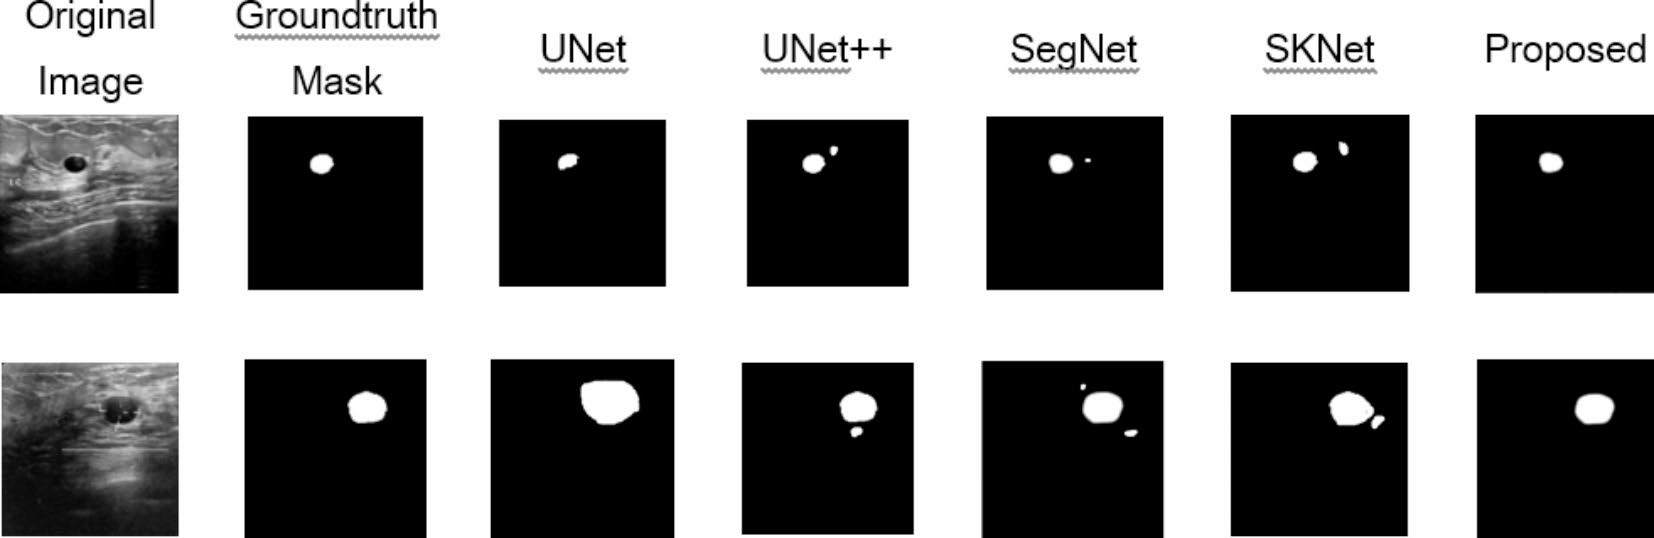

Aşağıdaki kod çalışmadı

In [ ]:
# import nibabel as nib
# import numpy as np
# import matplotlib.pyplot as plt

# # ==========================
# # 1. Dosya yollarını belirt
# # ==========================
# original_path   = "/content/drive/MyDrive/nnUNet_raw_data/Dataset001_MyTestTask/imagesTs/ispy1_1082_0000.nii.gz"
# gt_path         = "/content/drive/MyDrive/nnUNet_raw_data/Dataset001_MyTestTask/labelsTs/ispy1_1082.nii.gz"
# pred_path       = "/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/test_predictions/ispy1_1082.nii.gz"

# # ==========================
# # 2. Dosyaları yüklev
# # ==========================
# original_img = nib.load(original_path).get_fdata()
# gt           = nib.load(gt_path).get_fdata()
# pred         = nib.load(pred_path).get_fdata()

# # ==========================
# # 3. Slice seçimi
# # ==========================
# # Orijinal görüntünün boyutunu yazdıralım
# print("Orijinal görüntü boyutları (x, y, z):", original_img.shape)

# # Kullanıcıdan slice seçimi (z ekseni üzerinden)
# slice_idx = int(input(f"Bir slice seç (0 - {original_img.shape[2]-1} arası): "))

# # ==========================
# # 4. Görselleri hazırla
# # ==========================
# images = [
#     original_img[:, :, slice_idx],
#     gt[:, :, slice_idx],
#     pred[:, :, slice_idx],
# ]

# titles = ["Original Image", "Groundtruth", "Prediction"]

# # ==========================
# # 5. Görselleştirme
# # ==========================
# plt.figure(figsize=(12, 4))
# for i in range(len(images)):
#     plt.subplot(1, len(images), i+1)
#     plt.imshow(images[i], cmap="gray")
#     plt.title(titles[i], fontsize=10)
#     plt.axis("off")

# plt.tight_layout()
# plt.show()


Orijinal görüntü boyutları (x, y, z): (256, 256, 64)
Bir slice seç (0 - 63 arası): 35
